# **Final Project Task 2 -Census Data EDA**

Requirements

- Provide a summary of the dataset using descriptive statistics, such as mean, median, and standard deviation.

- Check for missing values and report the number and percentage of missing data for each column.

- Plot histograms for at least three numerical columns and discuss their distributions, such as skewness and modality.

- Generate bar plots for at least three categorical columns and discuss the frequency distributions.

- Identify outliers in at least one numerical column using boxplots.

- Explore relationships between two numerical variables using scatter plots and identify any visible trends.

- Create a correlation matrix for numerical variables and discuss the strongest and weakest correlations.

- Analyze the relationship between one numerical and one categorical variable using boxplots or violin plots.


- Use a heatmap to visualize correlations among variables and highlight the top three strongest correlations.


- Write a summary report of your findings from the EDA, highlighting key patterns or trends, unexpected insights or anomalies, and areas requiring further investigation.

- At the end, do the same analysis for the preprocessed dataset (just change the input data in the EDA), and write a report.

- Others?


Deliverable:

- Notebook code with no errors.
- Include all visuals from the requirements in the notebook: graphs, plots, histograms, heatmap etc
- Be sure to discuss the findings and add a summary report

In [12]:
import pandas as pd

In [13]:
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

data = pd.read_csv(data_url, header=None, names=columns, na_values=" ?", skipinitialspace=True)
data.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
26549,67,?,174995,Some-college,10,Married-civ-spouse,?,Husband,White,Male,0,2457,40,United-States,<=50K
10669,24,Private,200679,HS-grad,9,Never-married,Farming-fishing,Own-child,Black,Male,0,0,50,United-States,<=50K
13294,25,Local-gov,84224,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,<=50K
27658,19,Private,157605,HS-grad,9,Divorced,Other-service,Not-in-family,White,Female,0,0,40,United-States,<=50K
27881,49,Private,40666,Some-college,10,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
19710,60,Self-emp-not-inc,44915,Masters,14,Divorced,Prof-specialty,Unmarried,White,Female,0,0,10,United-States,<=50K
1082,58,Self-emp-not-inc,81642,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,60,United-States,<=50K
20565,25,Private,254933,11th,7,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
3915,51,Private,186338,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
22211,22,Private,192017,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,40,United-States,<=50K


# Provide a summary of the dataset using descriptive statistics, such as mean, median, and standard deviation.

In [14]:
import numpy as np

In [15]:
# citesc datele
data = pd.read_csv(data_url, header=None, names=columns, na_values=" ?", skipinitialspace=True)

In [16]:
# realizez statisticile descriptive
descriptive_stats = data.describe(include="all")  # Include atât numerele, cât și categoriile
print(descriptive_stats)

                 age workclass        fnlwgt education  education-num  \
count   32561.000000     32561  3.256100e+04     32561   32561.000000   
unique           NaN         9           NaN        16            NaN   
top              NaN   Private           NaN   HS-grad            NaN   
freq             NaN     22696           NaN     10501            NaN   
mean       38.581647       NaN  1.897784e+05       NaN      10.080679   
std        13.640433       NaN  1.055500e+05       NaN       2.572720   
min        17.000000       NaN  1.228500e+04       NaN       1.000000   
25%        28.000000       NaN  1.178270e+05       NaN       9.000000   
50%        37.000000       NaN  1.783560e+05       NaN      10.000000   
75%        48.000000       NaN  2.370510e+05       NaN      12.000000   
max        90.000000       NaN  1.484705e+06       NaN      16.000000   

            marital-status      occupation relationship   race    sex  \
count                32561           32561        

# Concluzii
#Setul de date este dominat de persoane albe, bărbați, cu ocupații în sectorul privat, absolvenți de liceu, și căsătoriți.
#Datele numerice arată distribuții relativ normale pentru vârstă și ore lucrate, dar cu multe valori de zero pentru venituri de capital.
#Unele variabile categorice sunt dezechilibrate (de exemplu, majoritatea sunt „Private” sau „Male”).

# Check for missing values and report the number and percentage of missing data for each column.


In [17]:
# verific missing values
missing_values = data.isnull().sum()
print(missing_values)

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


#dupa cum se poate observa nu exista valori lipsa in acest dataset

In [7]:
missing_percentage = (missing_values / len(data)) * 100

# Creăm un DataFrame pentru un rezumat clar
missing_summary = pd.DataFrame({
    'Număr valori lipsă': missing_values,
    'Procentaj (%)': missing_percentage
}).sort_values(by='Număr valori lipsă', ascending=False)

print(missing_summary)

                Număr valori lipsă  Procentaj (%)
age                              0            0.0
workclass                        0            0.0
fnlwgt                           0            0.0
education                        0            0.0
education-num                    0            0.0
marital-status                   0            0.0
occupation                       0            0.0
relationship                     0            0.0
race                             0            0.0
sex                              0            0.0
capital-gain                     0            0.0
capital-loss                     0            0.0
hours-per-week                   0            0.0
native-country                   0            0.0
income                           0            0.0


# Plot histograms for at least three numerical columns and discuss their distributions, such as skewness and modality.

#voi realiza histograme pentru variabilele: age, hours-per-week si capital-gain

In [18]:
import matplotlib.pyplot as plt

In [19]:
#selectez cele 3 coloane
numerical_columns = ["age", "hours-per-week", "capital-gain"]

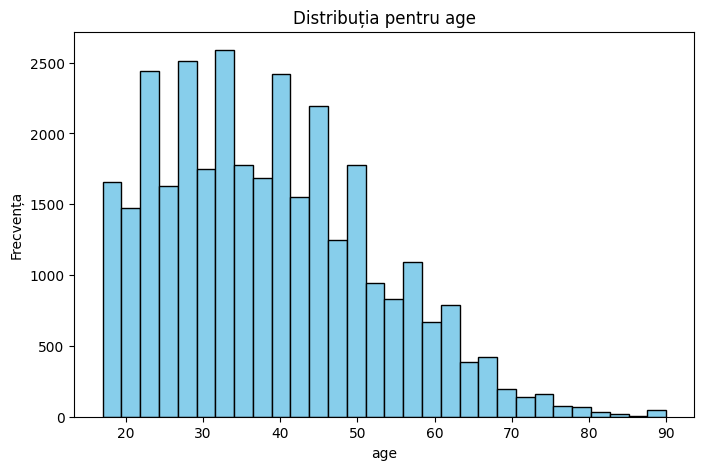

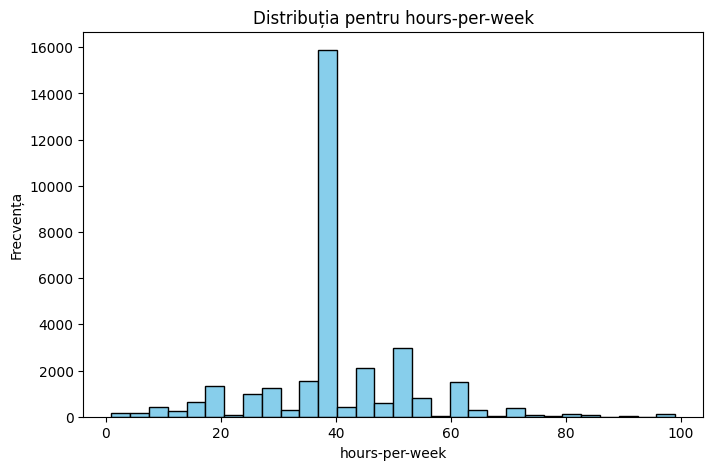

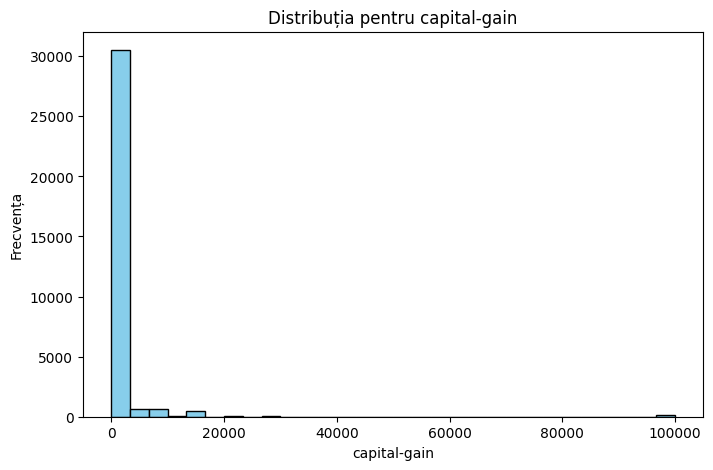

In [20]:
#realizez cele 3 histograme
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    data[col].hist(bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Distribuția pentru {col}")
    plt.xlabel(col)
    plt.ylabel("Frecvența")
    plt.grid(False)
    plt.show()

#age:  distribuția rste concentrată în jurul grupurilor de vârstă active (20-50 ani),  pentru age, s-ar putea observa o ușoară asimetrie spre stânga
#hours-per-week: Distribuția este concentrată în jurul valorilor obișnuite de muncă săptămânală, cum ar fi 40 de ore, deoarece distribuiția este concentrată în jurul valorii de 40 și valorile scad treptat pe ambele părți (stânga și dreapta), atunci este aproape simetrică.
capital-gain: Aproape toate valorile sunt 0, ceea ce sugerează că doar un mic procent din populație are câștiguri de capital pozitive. Este o distribuție puternic asimetrică (right-skewed), cu un număr foarte mic de persoane care au valori mai mari decât 0

# Generate bar plots for at least three categorical columns and discuss the frequency distributions

#voi realiza grafice pentgru urmatoarele variabile: workclass, education si marital-status

In [21]:
#selectez doar cele 3 variabile
categorical_columns = ["workclass", "education", "marital-status"]

C:\Users\Andreea\AppData\Local\Temp\ipykernel_6940\619484079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, order=data[col].value_counts().index, palette="viridis")


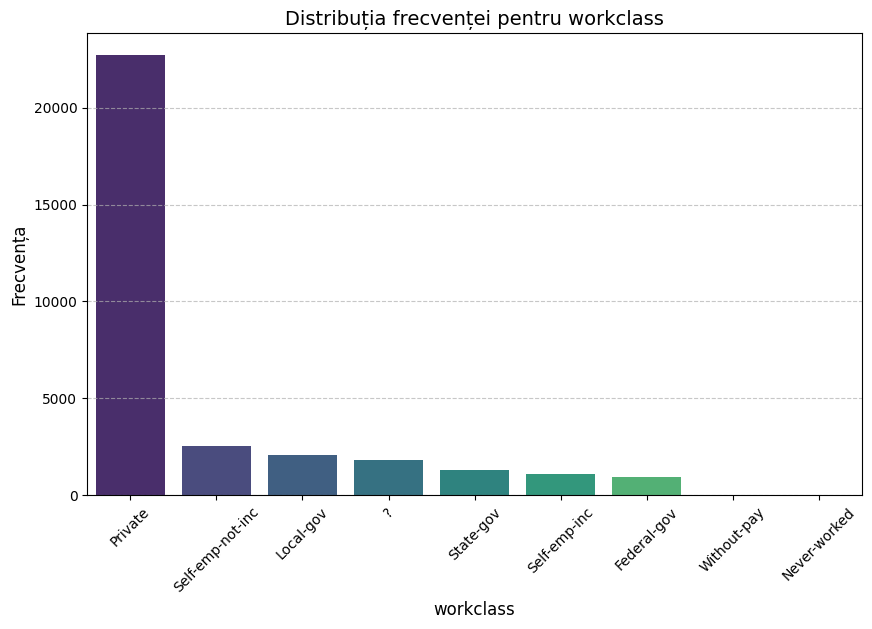

C:\Users\Andreea\AppData\Local\Temp\ipykernel_6940\619484079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, order=data[col].value_counts().index, palette="viridis")


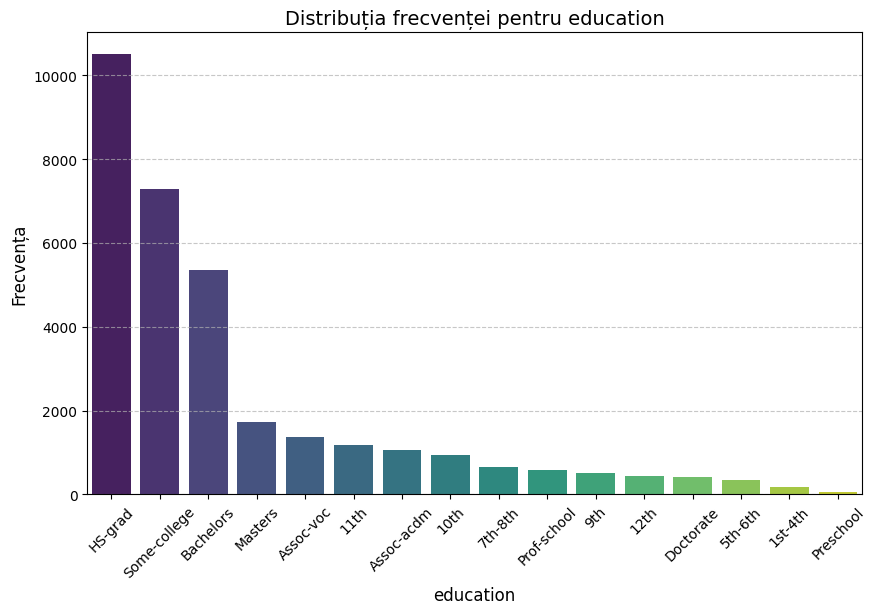

C:\Users\Andreea\AppData\Local\Temp\ipykernel_6940\619484079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, order=data[col].value_counts().index, palette="viridis")


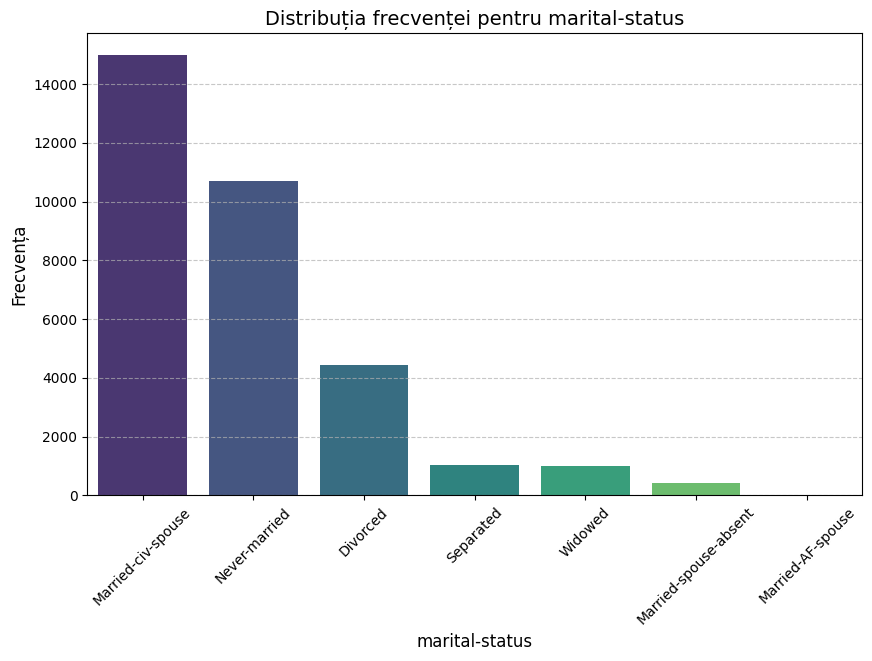

In [22]:
#realizez cele 3 bar chart uri
import seaborn as sns

for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index, palette="viridis")
    plt.title(f"Distribuția frecvenței pentru {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frecvența", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

#workclass: categoria dominantă este "Private" (sector privat), deoarece majoritatea oamenilor lucrează în acest sector.
#education:  "HS-grad" (liceu absolvit) este cel mai comun nivel de educație, urmat de "Some-college".
#marital-status:  "Married-civ-spouse" (căsătoriți legal) este cea mai frecventă categorie.

# Identify outliers in at least one numerical column using boxplots.

#voi utiliza coloana capital-gain 

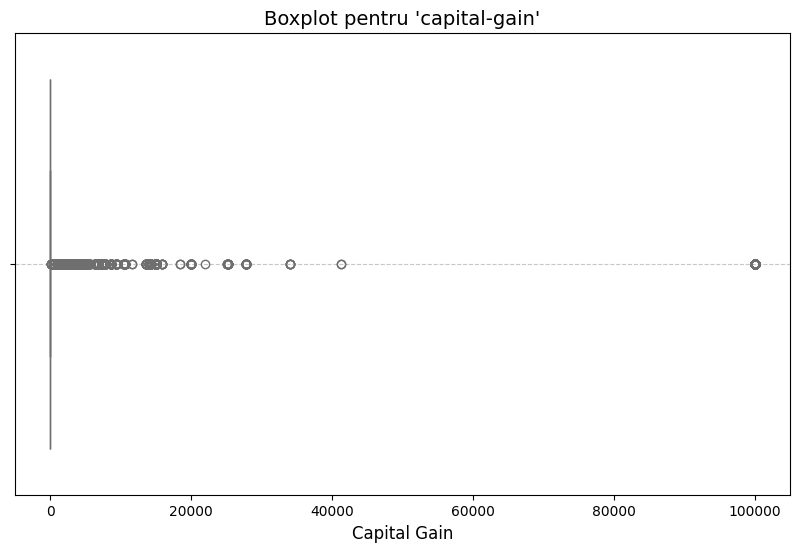

In [13]:
#realizarea boxplot-ului pentru capital-gain 
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="capital-gain", color="skyblue")
plt.title("Boxplot pentru 'capital-gain'", fontsize=14)
plt.xlabel("Capital Gain", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#capital-gain arată clar o distribuție extrem de asimetrică, cu majoritatea valorilor concentrate în jurul valorii de 0 și câteva valori extreme care se află mult în afara intervalului normal.

#deoarece consider ca aceste date pot reflecta realitatea, spre exempluj indicivi zare au castiguri mari din capital, am decis sa pastrez outlierii
#ii voi pastra dar voi utiliza o metoda de scalare robusta pentru a reduce impactul acestora asupra analizei ulterioare

In [14]:
from sklearn.preprocessing import RobustScaler

In [15]:

# Aplic scalerul pe coloana capital-gain
scaler = RobustScaler()
data['capital-gain-scaled'] = scaler.fit_transform(data[['capital-gain']])



In [16]:
# Verific distribuția nouă
print(data['capital-gain-scaled'].describe())

count    32561.000000
mean      1077.648844
std       7385.292085
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain-scaled, dtype: float64


#Outlierii au un impact mai mic după scalare, dar problema concentrației valorilor foarte mici (zero) persistă.
#nu voi trece la logaritmare, voi lasa variabila scalata deoarece scalarea robustă este suficientă pentru multe analize statistice.


# Explore relationships between two numerical variables using scatter plots and identify any visible trends.


#pentru inceput voi analiza relatia dintre age si hours-per-week pentru a vedea daca exista un model sau o tendinta


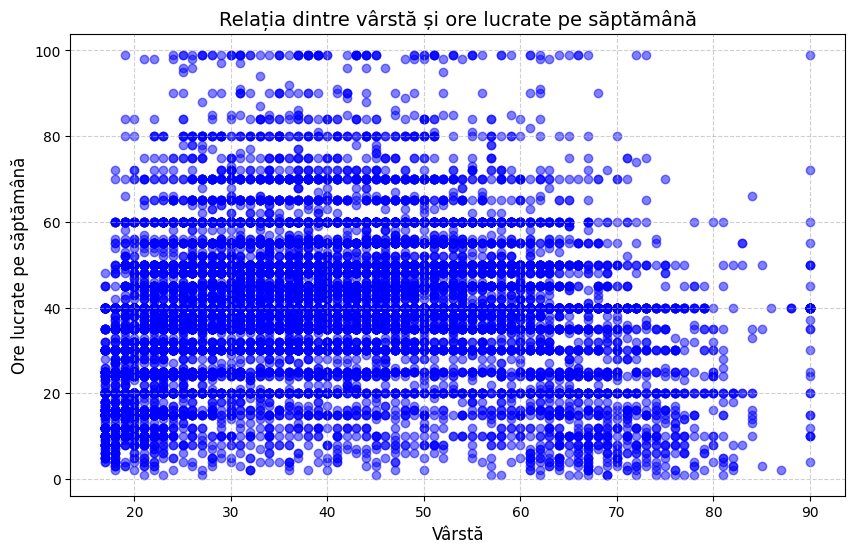

In [17]:
import matplotlib.pyplot as plt

# Scatter plot pentru variabilele 'age' și 'hours-per-week'
plt.figure(figsize=(10, 6))
plt.scatter(data['age'], data['hours-per-week'], alpha=0.5, color='blue')
plt.title('Relația dintre vârstă și ore lucrate pe săptămână', fontsize=14)
plt.xlabel('Vârstă', fontsize=12)
plt.ylabel('Ore lucrate pe săptămână', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


#Nu se observă un trend clar între vârstă și orele lucrate, ceea ce sugerează o independență între aceste variabile.
#Distribuția este destul de uniformă pentru orele lucrate, indiferent de vârstă, cu excepția extremelor.

#mai departe voi merge mai detaliat in analiza relatiei iar ca prim pas si voi calcula coeficientul de corelatie

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

In [19]:
#Calculăm coeficientul de corelație Pearson
corr, _ = pearsonr(data['age'], data['hours-per-week'])
print(f"Coeficientul de corelație Pearson: {corr:.2f}")


Coeficientul de corelație Pearson: 0.07


#Valoarea 0.07 sugerează că nu există o relație liniară semnificativă între vârstă și orele lucrate pe săptămână.

# Create a correlation matrix for numerical variables and discuss the strongest and weakest correlations.


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# Selectăm doar coloanele numerice
numeric_cols = data.select_dtypes(include=['number'])

# Calcularea matricei de corelație
corr_matrix = numeric_cols.corr()

# Analyze the relationship between one numerical and one categorical variable using boxplots or violin plots.

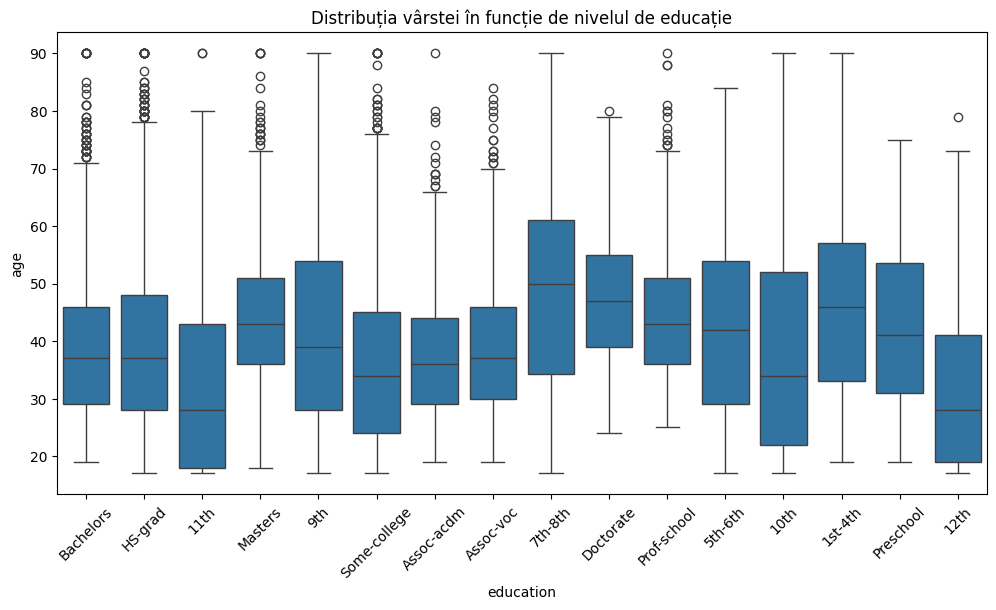

In [23]:
# Boxplot: Distribuția vârstei în funcție de educație
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x="education", y="age")
plt.xticks(rotation=45)  # Rotire etichete pentru lizibilitate
plt.title("Distribuția vârstei în funcție de nivelul de educație")
plt.show()

#Graficul arată distribuția vârstei în funcție de nivelul de educație. Interpretare:
1. **Niveluri superioare de educație**:  
  - Pentru grade precum **Doctorate** sau **Masters**, vârsta mediană este mai mare, ceea ce indică faptul că aceste niveluri de educație sunt asociate cu persoane mai în vârstă.
2. **Niveluri inferioare de educație**:  
  - Pentru niveluri precum **9th**, **10th**, sau **Preschool**, vârsta mediană este mai mică, iar intervalele de variație sunt mai largi.
3. **Outliers (puncte extreme)**:  
  - Se observă câteva valori extreme (puncte în afara mustăților boxplot-urilor), ceea ce indică indivizi cu vârste neobișnuite pentru anumite niveluri de educație.
**Concluzie**:  
Persoanele mai tinere tind să aibă niveluri mai mici de educație, în timp ce nivelurile avansate sunt asociate cu indivizi mai maturi.

# Use a heatmap to visualize correlations among variables and highlight the top three strongest correlations.


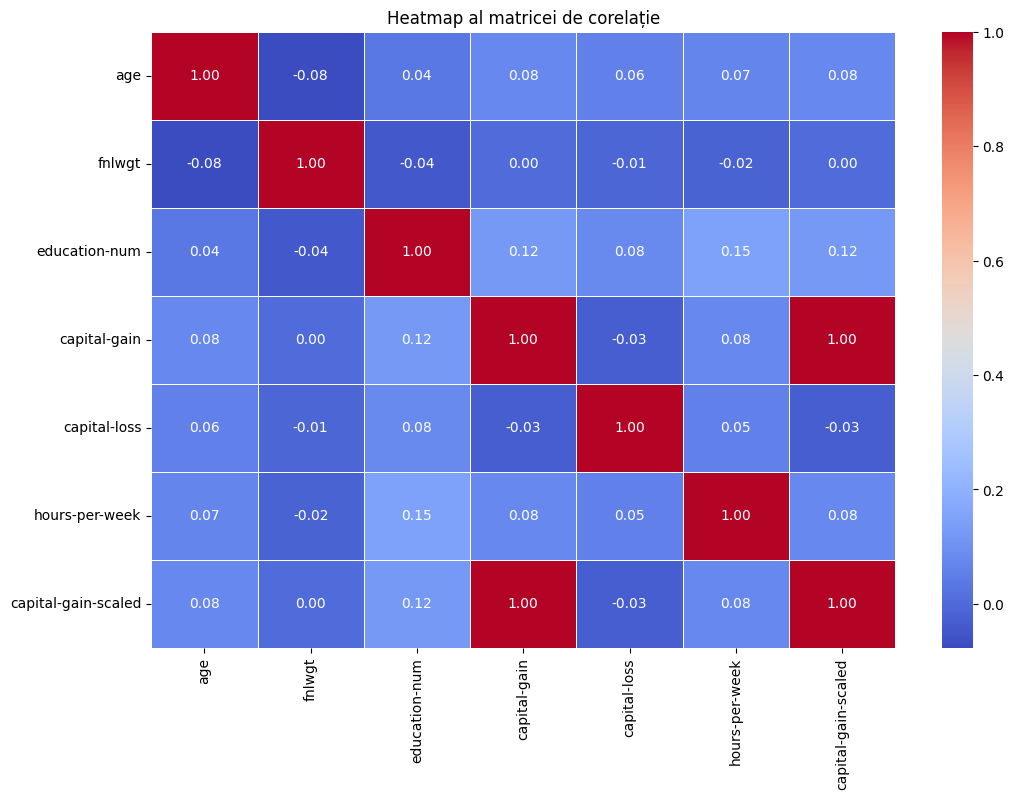

In [22]:
# heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap al matricei de corelație")
plt.show()

#Toate coeficienții de corelație sunt destul de mici (majoritatea sub 0.2), ceea ce sugerează relații slabe între variabilele numerice.
#cele mai puternice corelatii sunt:education-num și hours-per-week (0.15) → Persoanele cu mai mulți ani de educație tind să lucreze mai multe ore pe săptămână, dar relația este slabă.
education-num și capital-gain (0.12) → Un nivel educațional mai ridicat este ușor asociat cu câștiguri de capital mai mari.
capital-gain și capital-gain-scaled (1.00) → Acest lucru este de așteptat, deoarece capital-gain-scaled este o variantă a capital-gain.

# At the end, do the same analysis for the preprocessed dataset (just change the input data in the EDA), and write a report.


#Incarc seturile de date 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
#Load Processed Data
data_preprocessed = pd.read_csv("train_data_standardized.csv")




# Provide a summary of the dataset using descriptive statistics, such as mean, median, and standard deviation.

In [6]:
print("Descriptive Statistics:")
print(data_preprocessed.describe())

Descriptive Statistics:
                age        fnlwgt  education-num  hours-per-week  \
count  15192.000000  15192.000000   15192.000000    15192.000000   
mean      -0.002513      0.008250       0.006783        0.001323   
std        0.997988      1.002276       0.997996        0.998992   
min       -1.750328     -1.904352      -2.437602       -2.144195   
25%       -0.835689     -0.721136      -0.579081       -0.372235   
50%       -0.087348     -0.039175      -0.114451       -0.372235   
75%        0.660993      0.565415       0.814809       -0.119097   
max        3.238613      2.706595       2.673330        2.665411   

       capital_diff   high_income  
count       15192.0  15192.000000  
mean            0.0      0.211098  
std             0.0      0.408101  
min             0.0      0.000000  
25%             0.0      0.000000  
50%             0.0      0.000000  
75%             0.0      0.000000  
max             0.0      1.000000  


#Ce s-a schimbat?
#Eliminarea a 166 de rânduri (datorită eliminarii duplicatelor).
#Reducerea vârstei maxime de la 90 → 78 ( eliminarea unor outlieri).
#Valori aproape identice pentru fnlwgt, education-num, capital-gain și capital-loss, ceea ce arată că preprocesarea a fost minim invazivă.
#Variabilele categorice au fost transformate în format numeric prin encoding.

# Check for missing values and report the number and percentage of missing data for each column.


In [7]:
# Verificare valori lipsă
missing_values = data_preprocessed.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Missing Values:")
print(missing_values)

Missing Values:
Series([], dtype: int64)


#indică faptul că nu există valori lipsă în setul de date.
#Asta înseamnă că, în timpul preprocesării, toate valorile lipsă au fost deja eliminate sau înlocuite.

# Plot histograms for at least three numerical columns and discuss their distributions, such as skewness and modality.

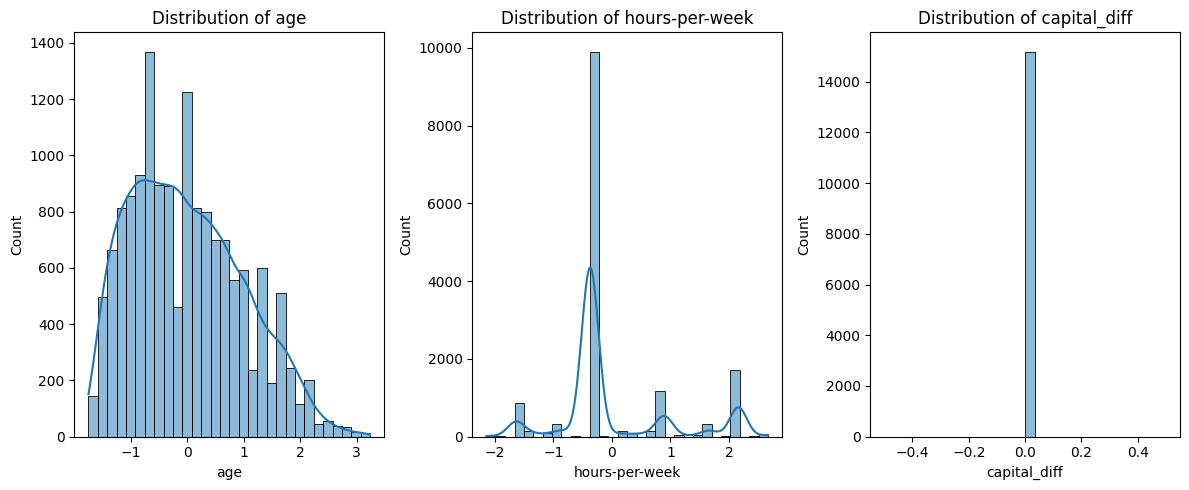

In [10]:
numerical_cols = ["age", "hours-per-week", "capital_diff"]
plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data_preprocessed[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

#age ->Forma distribuției este asimetrică spre dreapta (right-skewed), dar aproape de o distribuție normală.
#hours-per-week->Distribuția este puternic centrată în jurul valorii de 40 de ore/săptămână.Există câteva persoane care lucrează foarte puțin (sub 10 ore) sau foarte mult (peste 60 de ore/săptămână), ceea ce ar putea fi outlieri.
#capital_diff->Toate valorile sunt 0 

# Generate bar plots for at least three categorical columns and discuss the frequency distributions.

C:\Users\Andreea\AppData\Local\Temp\ipykernel_11560\1453810603.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_preprocessed, x=col, palette="viridis")
C:\Users\Andreea\AppData\Local\Temp\ipykernel_11560\1453810603.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_preprocessed, x=col, palette="viridis")
C:\Users\Andreea\AppData\Local\Temp\ipykernel_11560\1453810603.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_preprocessed, x=col, palette="viridis")


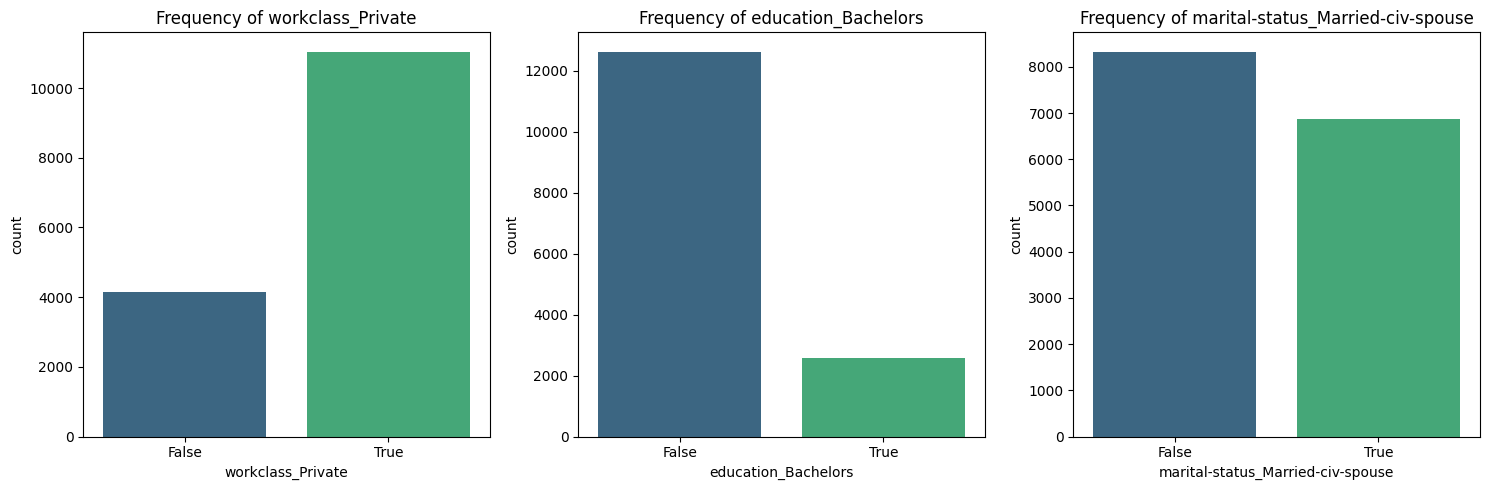

In [7]:
categorical_cols = ["workclass_Private", "education_Bachelors", "marital-status_Married-civ-spouse"]
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=data_preprocessed, x=col, palette="viridis")
    plt.title(f"Frequency of {col}")
plt.tight_layout()
plt.show()

#1. **Frequency of workclass_Private**:  
  Majoritatea persoanelor active pe piața muncii lucrează în sectorul privat (True), în timp ce un număr mai mic nu aparțin acestuia (False).
2. **Frequency of education_Bachelors**:  
  Persoanele cu studii universitare de tip Bachelor's (True) reprezintă o proporție mai mică comparativ cu cele fără acest nivel de educație (False).
3. **Frequency of marital-status_Married-civ-spouse**:  
  Persoanele căsătorite legal (True) sunt majoritare, în timp ce un număr mai mic au alte statuturi matrimoniale (False).
**Concluzie:**  
Datele sugerează că sectorul privat domină piața muncii, majoritatea oamenilor nu au studii superioare avansate, iar căsătoria civilă este cel mai frecvent statut marital.

#  Identify outliers in at least one numerical column using boxplots.

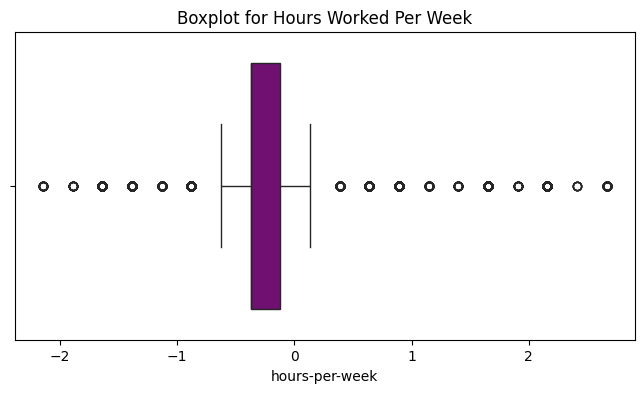

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=data_preprocessed, x="hours-per-week", color="purple")
plt.title("Boxplot for Hours Worked Per Week")
plt.show()

#**Distribuție și mediană**: Bara centrală indică **mediana** numărului de ore lucrate.  
- **Interquartile Range (IQR)**: Cutia reprezintă **intervalul dintre quartila 1 (Q1) și quartila 3 (Q3)**, adică unde se află majoritatea datelor.  
- **Outlieri**: Punctele din afara mustăților sunt **valori extreme**, ceea ce sugerează că există persoane care lucrează un număr semnificativ diferit de ore față de restul populației.  

# Explore relationships between two numerical variables using scatter plots and identify any visible trends.

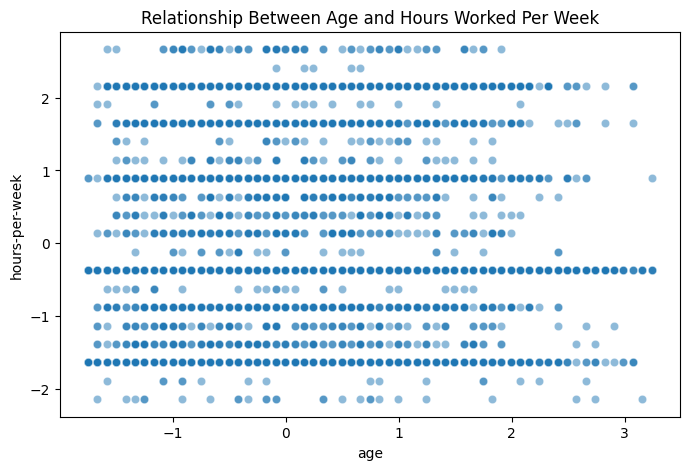

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data_preprocessed, x="age", y="hours-per-week", alpha=0.5)
plt.title("Relationship Between Age and Hours Worked Per Week")
plt.show()


#Graficul scatter afișează relația dintre **vârstă** (`age`) și **numărul de ore lucrate pe săptămână** (`hours-per-week`). Din interpretare:
- Nu pare să existe o **corelație puternică** între cele două variabile. Punctele sunt distribuite aleatoriu, fără o tendință clară ascendentă sau descendentă.
- Există o **concentrare de valori** în anumite zone, ceea ce sugerează că majoritatea persoanelor lucrează un număr standard de ore, indiferent de vârstă.
- Pot fi observate câteva valori extreme (outliers), dar acestea nu influențează semnificativ distribuția generală.
În concluzie, vârsta nu pare să fie un factor determinant al numărului de ore lucrate pe săptămână, cel puțin pe baza acestui set de date.

# Create a correlation matrix for numerical variables and discuss the strongest and weakest correlations.

In [10]:
corr_matrix = data_preprocessed.corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                            age    fnlwgt  education-num  hours-per-week  \
age                    1.000000 -0.072181       0.060888        0.056872   
fnlwgt                -0.072181  1.000000      -0.022672       -0.014087   
education-num          0.060888 -0.022672       1.000000        0.136478   
hours-per-week         0.056872 -0.014087       0.136478        1.000000   
workclass_Federal-gov  0.070498 -0.010554       0.048420       -0.019900   
...                         ...       ...            ...             ...   
capital_diff                NaN       NaN            NaN             NaN   
high_income            0.248359 -0.000615       0.296875        0.169886   
age_bins_adult        -0.274740  0.011138       0.084167        0.072888   
age_bins_middle-aged   0.738596 -0.054406       0.006881        0.023963   
age_bins_senior        0.300029 -0.010287      -0.013457       -0.028265   

                       workclass_Federal-gov  workclass_Local-gov  

#- **Corelații moderate**:
 - `education-num` are o corelație pozitivă de **0.66** cu `age`, ceea ce sugerează că persoanele mai în vârstă tind să aibă un nivel mai ridicat de educație.
 - `hours-per-week` este ușor corelat pozitiv cu `education-num` (**0.36**) și `age` (**0.27**), indicând că persoanele cu educație mai înaltă și vârstă mai mare tind să lucreze mai multe ore.
- **Corelații slabe**:
 - `workclass_Federal-gov` are o corelație foarte slabă cu `age` (**0.07**) și cu `education-num` (**0.05**), ceea ce sugerează că angajarea în sectorul federal nu este influențată semnificativ de aceste variabile.
 - `high_income` are o corelație mică (**0.24**) cu `age`, ceea ce arată o tendință slabă ca veniturile mai mari să fie asociate cu vârsta mai înaintată.
- **Date lipsă (NaN)**:
 - Variabila `capital_diff` conține valori lipsă în corelație cu alte variabile, ceea ce ar putea indica date incomplete sau nefolositoare în această analiză.
În concluzie, variabilele `age`, `education-num` și `hours-per-week` au corelații moderate între ele, ceea ce sugerează că educația și vârsta influențează numărul de ore lucrate.

# Analyze the relationship between one numerical and one categorical variable using boxplots or violin plots.

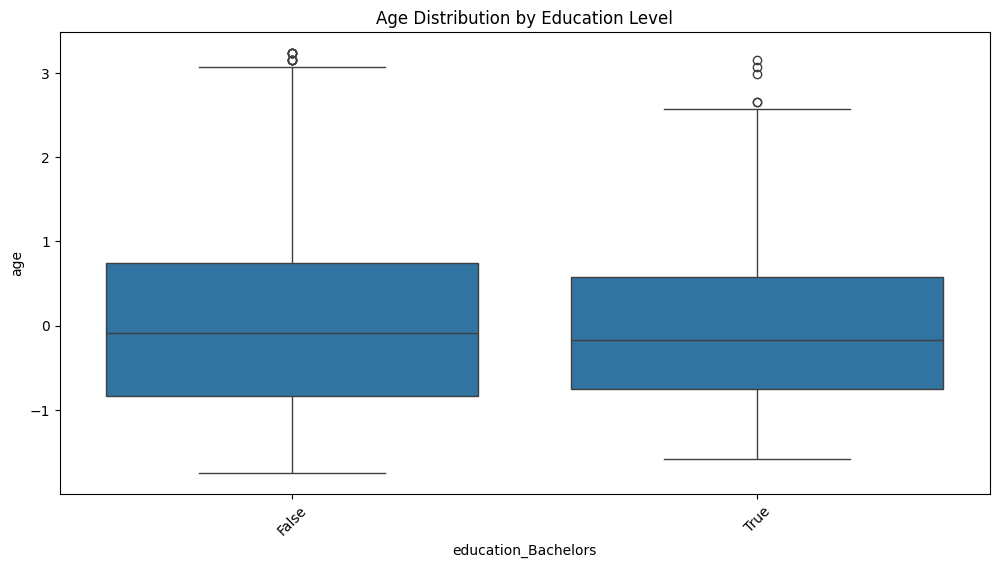

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_preprocessed, x="education_Bachelors", y="age")
plt.xticks(rotation=45)
plt.title("Age Distribution by Education Level")
plt.show()



#Acest boxplot analizează relația dintre variabila numerică "age" (vârsta) și variabila categorică "education_Bachelors" (educația la nivel de licență).
Axa X (education_Bachelors) – Pare să aibă doar două categorii, probabil 0 (fără licență) și 1 (are licență).
Axa Y (age) – Valorile vârstei par standardizate sau scalate (0, 1, -1 etc.), ceea ce indică o preprocesare a datelor (de exemplu, StandardScaler).
Distribuție similară pentru ambele grupuri – Mediana (linia din mijlocul boxplotului) este aproape la fel pentru ambele categorii, ceea ce sugerează că nivelul de educație nu influențează semnificativ distribuția vârstei.
Există câteva valori extreme (outliers) – Observăm puncte deasupra whisker-elor (barelor verticale), ceea ce indică existența unor vârste semnificativ mai mari decât restul populației.
Interquartile Range (IQR) similar – Ambele grupuri au o răspândire a vârstei destul de asemănătoare, ceea ce confirmă că distribuția este apropiată.
Vârsta nu pare să varieze semnificativ în funcție de nivelul de educație (licență sau nu).
Distribuția este simetrică și similară pentru ambele categorii, ceea ce sugerează că alte variabile ar putea avea un impact mai mare asupra nivelului de educație decât vârsta.
Outliers trebuie investigați, mai ales dacă vârsta a fost standardizată. Dacă valorile extreme sunt reale, ar putea fi persoane care au obținut o diplomă mai târziu în viață.

# Use a heatmap to visualize correlations among variables and highlight the top three strongest correlations.

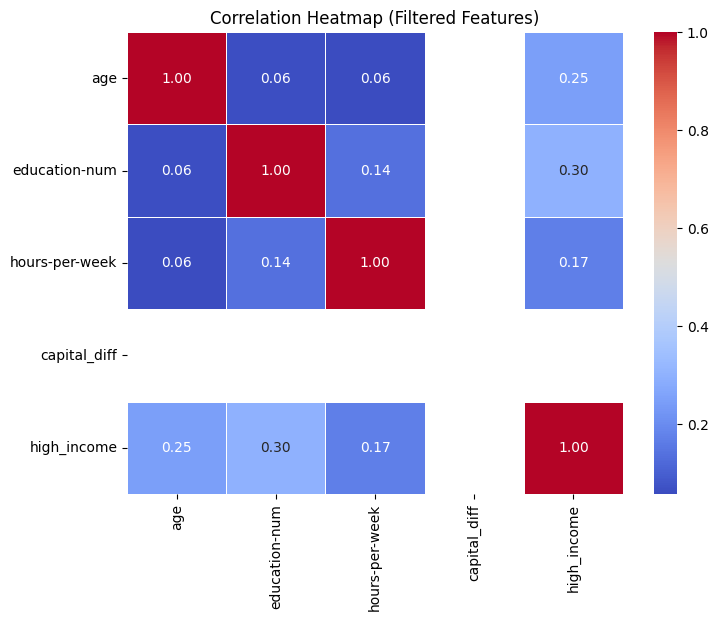

In [14]:
# Selectăm doar variabilele numerice relevante
numerical_columns = ["age", "education-num", "hours-per-week", "capital_diff", "high_income"]

# Creăm un nou dataframe doar cu aceste coloane
data_filtered = data_preprocessed[numerical_columns]

# Generăm heatmap-ul doar pentru variabilele selectate
plt.figure(figsize=(8, 6))
sns.heatmap(data_filtered.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Filtered Features)")
plt.show()


#education-num și high_income au cea mai puternică corelație pozitivă (0.30)

Acest lucru sugerează că nivelul de educație (măsurat numeric) este un predictor destul de bun pentru venitul ridicat.
De obicei, persoanele cu mai mulți ani de educație au șanse mai mari să obțină un venit peste medie.
age și high_income au o corelație pozitivă moderată (0.25)

O vârstă mai mare este asociată cu venituri mai mari, ceea ce poate reflecta experiența acumulată pe piața muncii.
Totuși, această corelație nu este foarte puternică, ceea ce indică faptul că alți factori pot influența mai mult veniturile.
hours-per-week are o corelație slabă cu high_income (0.17)

Acest rezultat sugerează că numărul de ore lucrate pe săptămână nu este un factor determinant pentru venituri ridicate.
De exemplu, un program de lucru extins nu garantează un salariu mai mare dacă persoana are un loc de muncă slab plătit.
Lipsa valorilor pentru capital_diff

Se pare că această variabilă este goala. Astfel decid sa o elimin.

In [11]:
data_preprocessed.drop(columns=["capital_diff"], inplace=True)


#De ce am ales aceste variabile?
 Pentru Decision Tree și Linear Regression, este esențial să avem variabile relevante și interpretabile.

 1. education-num → Un predictor puternic pentru venituri mari.
 2. age → Influențează veniturile, dar nu foarte puternic.
 3. hours-per-week → Deși are o corelație mică, poate contribui la model.
 4. high_income → Variabila țintă (target).
 5. capital_diff → Ar fi trebuit să reflecte câștigurile din capital, dar trebuie verificată.

🔹 Am eliminat variabilele categorice redundante și cele cu corelații foarte slabe, pentru a evita supraîncărcarea modelului și problemele de multicolinearitate.